In [1]:
import re
from pathlib import Path
import pandas as pd
from multiprocessing import Pool, cpu_count

#on utilise spacy
USE_SPACY = True
try:
    import spacy
    nlp = spacy.load("fr_core_news_md")
except:
    USE_SPACY = False

#on charge un dataset de prénoms français qui servira pour la détection de genre
try:
    import json
    with open("prenoms_fr.json", encoding="utf-8") as f:
        PRENOMS = json.load(f)
except:
    PRENOMS = {}

#on nettoie le texte pour faciliter les analyses ultérieures
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâéèêîôûç0-9 ]", " ", text)
    return text

#récupérer le nom, prénom du candidat
import re
import unicodedata

def extract_candidate(text, PRENOMS):

    def normalize(s):
        s = s.lower()
        s = unicodedata.normalize("NFD", s)
        s = "".join(c for c in s if unicodedata.category(c) != "Mn")
        return re.sub(r"[^a-z\- ]", "", s)

    def is_name_token(w):
        w_norm = normalize(w)
        return w_norm in PRENOMS

    BAD_WORDS = {
        "votez", "elections", "legislatives", "circonscription",
        "suppléante", "suppléant", "maire", "adjoint",
        "socialiste", "republique", "gauche", "droite"
    }

    lines = text.split("\n")

    candidates = []

    for line in lines:
        raw = line.strip()
        if not raw:
            continue

        # split tokens
        words = re.findall(r"[A-Za-zÀ-ÿ\-]+", raw)

        if not (2 <= len(words) <= 4):
            continue

        norm_words = [normalize(w) for w in words]

        # skip slogans / bruit
        if any(w in BAD_WORDS for w in norm_words):
            continue

        score = 0

        # BONUS: format NOM prénom ou Prénom NOM
        cap_words = sum(1 for w in words if w[0].isupper())
        score += cap_words

        # BONUS prénom détecté
        if words and is_name_token(words[0]):
            score += 2

        if len(words) >= 2 and is_name_token(words[1]):
            score += 2

        # BONUS ligne courte = souvent nom candidat
        if len(words) == 2:
            score += 2

        # BONUS majuscules typiques affiches
        if all(w.isupper() for w in words):
            score += 2

        if score >= 3:
            candidates.append((" ".join(words), score))

    if not candidates:
        return None

    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates[0][0].upper()

#fonction pour deviner le genre à partir du prénom
def guess_gender(name):
    if not name:
        return None

    first_name = name.split()[0].lower()

    if first_name in PRENOMS:
        return PRENOMS[first_name]

    # fallback heuristique légère
    if first_name.endswith("e"):
        return "female"
    return "male"

#ici pour retrouver le parti politique, on peut faire une liste de mots-clés
PARTIES = [
    "PSU", "PS", "PCF", "RPR", "UDF", "FN", "LREM",
    "PARTI SOCIALISTE", "PARTI COMMUNISTE",
    "GAULLISTE"
]

def extract_party(text):
    text_upper = text.upper()
    for party in PARTIES:
        if party in text_upper:
            return party
    return None

#pareil pour le soutien, on cherche des expressions clés
def extract_support(text):
    match = re.search(
        r"(investi par|soutenu par|candidat de|avec le soutien de)\s*[:\-]?\s*(.+?)(\.|\n)",
        text,
        re.IGNORECASE
    )
    return match.group(2).strip() if match else None

#on est maintenant prêt à extraire toutes les métadonnées d'un texte donné
def extract_metadata(text):
    metadata = {}
    PRENOMS = {
    # masculins très fréquents
    "jean": "male",
    "pierre": "male",
    "paul": "male",
    "michel": "male",
    "jacques": "male",
    "andre": "male",
    "philippe": "male",
    "bernard": "male",
    "alain": "male",
    "didier": "male",
    "françois": "male",
    "francois": "male",
    "thierry": "male",
    "patrick": "male",
    "nicolas": "male",
    "christophe": "male",
    "serge": "male",
    "dominique": "male",
    "laurent": "male",
    "eric": "male",
    "erick": "male",
    "pascal": "male",
    "marc": "male",
    "henri": "male",
    "roger": "male",
    "gerard": "male",
    "gérard": "male",
    "luc": "male",
    "francis": "male",
    "vincent": "male",
    "olivier": "male",
    "christian": "male",
    "daniel": "male",
    "robert": "male",
    "yves": "male",
    "bernard": "male",
    "guy": "male",
    "henri": "male",

    # féminins fréquents
    "marie": "female",
    "anne": "female",
    "monique": "female",
    "francoise": "female",
    "françoise": "female",
    "nathalie": "female",
    "isabelle": "female",
    "sylvie": "female",
    "dominique": "female",
    "patricia": "female",
    "catherine": "female",
    "veronique": "female",
    "véronique": "female",
    "martine": "female",
    "brigitte": "female",
    "christine": "female",
    "claudine": "female",
    "nicole": "female",
    "chantal": "female",
    "laure": "female",
    "aline": "female",
    "helene": "female",
    "hélène": "female",
    "sophie": "female",
    "isabelle": "female",
    "jacqueline": "female",
    "jeanne": "female",
    "madeleine": "female",
    "lucie": "female",
    "emmanuelle": "female"
    }
    text_upper = text.upper()

    # YEAR
    year_match = re.search(r"(19|20)\d{2}", text)
    metadata["year"] = year_match.group(0) if year_match else None

    # TYPE
    if "LÉGISLATIVES" in text_upper or "LEGISLATIVES" in text_upper:
        metadata["type_election"] = "legislatives"
    elif "PRÉSIDENTIELLE" in text_upper or "PRESIDENTIELLE" in text_upper:
        metadata["type_election"] = "presidentielle"
    else:
        metadata["type_election"] = None

    # CANDIDATE
    candidate = extract_candidate(text, PRENOMS)
    metadata["candidate"] = candidate

    # GENDER
    metadata["gender"] = guess_gender(candidate)

    # PARTY
    metadata["party_list"] = extract_party(text)

    # SUPPORT
    metadata["titulaire_soutien"] = extract_support(text)

    return metadata

#fonction pour convertir un fichier texte en une ligne de dataframe avec les métadonnées extraites
def process_file(file_path):
    try:
        raw_text = file_path.read_text(encoding="utf-8", errors="ignore")

        meta = extract_metadata(raw_text)
        cleaned = clean_text(raw_text)

        return {
            "text": cleaned,
            "filename": file_path.stem,
            **meta
        }
    except Exception as e:
        return {
            "text": None,
            "filename": file_path.stem,
            "error": str(e)
        }

#construction du dataframe sur lequel on va travailler
def build_dataframe(base_path="text_files"):
    base = Path(base_path)

    files = list(base.glob("**/*.txt"))

    print(f"{len(files)} files found")

    with Pool(cpu_count()) as p:
        data = p.map(process_file, files)

    df = pd.DataFrame(data)

    return df

df = build_dataframe()

21697 files found


In [3]:
print(df.gender.head(50))

#here we can do a little bit of descriptive statistics
def describe_dataframe(df):
    print("Dimension du dataframe :", df.shape)

    print("\nValeurs manquantes :")
    print(df.isna().sum())

    print("\nNombre de types d'élection :")
    print(df["type_election"].value_counts(dropna=False))

    print("\nNombre de chaque genre :")
    print(df["gender"].value_counts(dropna=False))

    print("\nNombre pour chaque année :")
    print(df["year"].value_counts().sort_index())

    print("\nNombre de chaque parti (10 meilleurs):")
    print(df["party_list"].value_counts().head(10))

    print("\nNombre de chaque soutien (10 meilleurs):")
    print(df["titulaire_soutien"].value_counts().head(10))

    print("Unique candidates:", df["candidate"].nunique())
    print("Missing candidates:", df["candidate"].isna().sum())

    print("\nInfos sur les textes :")
    df["text_length"] = df["text"].apply(lambda x: len(x) if isinstance(x, str) else 0)
    print(df["text_length"].describe())

    print("\nInfos sur les mots :")
    df["word_count"] = df["text"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    print(df["word_count"].describe())

describe_dataframe(df)

0       male
1       male
2       male
3     female
4     female
5     female
6     female
7       male
8       male
9       male
10      male
11      male
12      male
13      male
14      male
15    female
16      male
17    female
18    female
19    female
20      male
21      male
22      male
23    female
24    female
25    female
26    female
27      male
28      male
29    female
30    female
31      male
32      male
33    female
34      male
35    female
36      male
37      male
38      male
39      male
40      male
41      male
42      male
43    female
44      male
45    female
46      male
47      male
48      male
49    female
Name: gender, dtype: str
Dimension du dataframe : (21697, 10)

Valeurs manquantes :
text                     0
filename                 0
year                  1372
type_election         1987
candidate              207
gender                 207
party_list            5083
titulaire_soutien    16617
text_length              0
word_count             

<Axes: xlabel='length', ylabel='Count'>

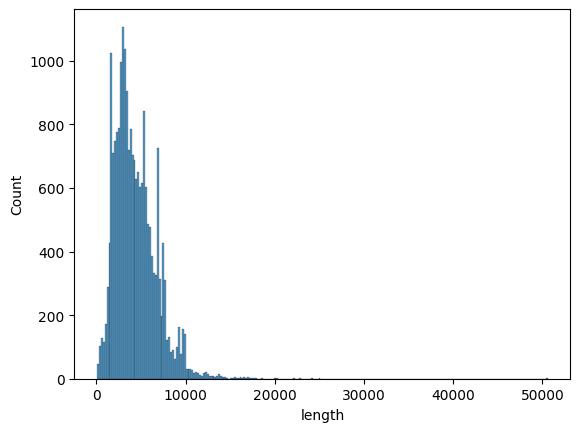

In [4]:
import seaborn as sns

#we visualize the distribution of text lengths
df["length"] = df["text"].apply(len)
sns.histplot(df["length"])

In [6]:
#detecting gender style using logistic regression on the text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

#on enlève là où le genre est manquant
df = df.dropna(subset=["gender"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["gender"], test_size=0.3
)

vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


clf = LogisticRegression()
clf.fit(X_train_vec, y_train)
print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.7887389483480689


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
#detecting party style using multinomial naive bayes on the text

#on enlève là où le parti est manquant
df = df.dropna(subset=["party_list"])

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["party_list"], test_size=0.2
)

vectorizer = CountVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.4951278928136419


In [8]:
#accuracy is around 0.49 which is not great, we try something else
#same for TfidfVectorizer instead of CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf = MultinomialNB()
clf.fit(X_train_vec, y_train)

print("Accuracy:", clf.score(X_test_vec, y_test))

Accuracy: 0.6729598051157125


                  precision    recall  f1-score   support

              FN       0.27      0.39      0.32        41
       GAULLISTE       1.00      0.05      0.10        39
PARTI COMMUNISTE       0.61      0.17      0.27       207
PARTI SOCIALISTE       0.61      0.42      0.50       592
             PCF       0.00      0.00      0.00        35
              PS       0.69      0.91      0.79      1982
             PSU       0.90      0.50      0.64       105
             RPR       0.55      0.24      0.33       263
             UDF       0.00      0.00      0.00        20

        accuracy                           0.67      3284
       macro avg       0.51      0.30      0.33      3284
    weighted avg       0.66      0.67      0.63      3284



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

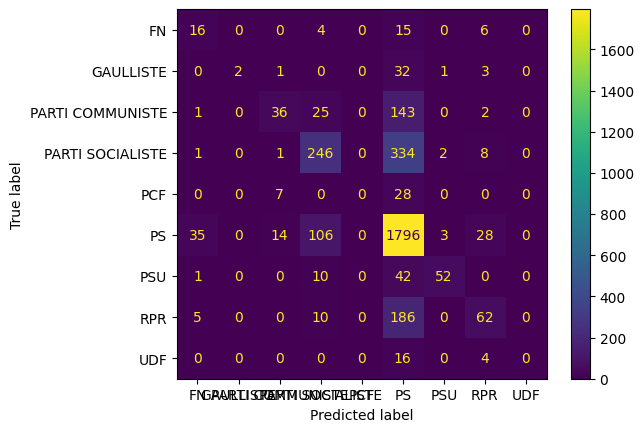

In [9]:
#it's a little bit better but still not great, we can try to look at the confusion matrix to see where it fails
#creating confusion matrix for the party classification

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred = clf.predict(X_test_vec)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [11]:
#now we try to visualize in 2D the text embeddigns for semantic similarity, with party/potitical support
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import umap
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(df["text"].fillna("").tolist(), show_progress_bar=True)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

df["x"] = embedding_2d[:, 0]
df["y"] = embedding_2d[:, 1]


plt.figure(figsize=(12, 8))

# couleur = party list
for label in df["party_list"].fillna("UNKNOWN").unique():
    subset = df[df["party_list"] == label]
    plt.scatter(subset["x"], subset["y"], label=label, s=10)

plt.legend()
plt.title("Semantic space of political documents")
plt.show()

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'umap'

In [ ]:
#last thing to do is to identify outliers of the semantic space

from sklearn.metrics import pairwise_distances
import numpy as np

dist = pairwise_distances(embedding_2d, metric="euclidean")

mean_dist = dist.mean(axis=1)
df["outlier_score"] = mean_dist

outliers = df.sort_values("outlier_score", ascending=False).head(20)

plt.figure(figsize=(12, 8))

plt.scatter(df["x"], df["y"], s=10, alpha=0.5)

plt.scatter(
    outliers["x"],
    outliers["y"],
    color="red",
    s=50,
    label="Outliers"
)

plt.legend()
plt.title("Semantic space with outliers")
plt.show()